In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names for C-MAPSS FD001
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

# Load data (relative path from notebooks/ folder)
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())
print("\nUnique engines:", df['unit'].nunique())

Shape: (20631, 26)

First 5 rows:
   unit  cycle     op1     op2    op3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  3

In [2]:
# Get the last cycle (failure point) for each engine
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

# Merge back and compute RUL
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

print("RUL column created.\n")
print(df[['unit', 'cycle', 'RUL']].head(10))
print("\nRUL statistics:")
print(df['RUL'].describe())

RUL column created.

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


In [3]:
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [col for col in sensor_cols if df[col].std() == 0]

print("Constant sensors to drop:", constant_sensors)

df.drop(columns=constant_sensors, inplace=True)

active_sensors = [col for col in df.columns if col.startswith('s')]
print(f"\nActive sensors ({len(active_sensors)}):", active_sensors)
print("\nFinal shape:", df.shape)

Constant sensors to drop: ['s1', 's10', 's18', 's19']

Active sensors (17): ['s2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21']

Final shape: (20631, 23)


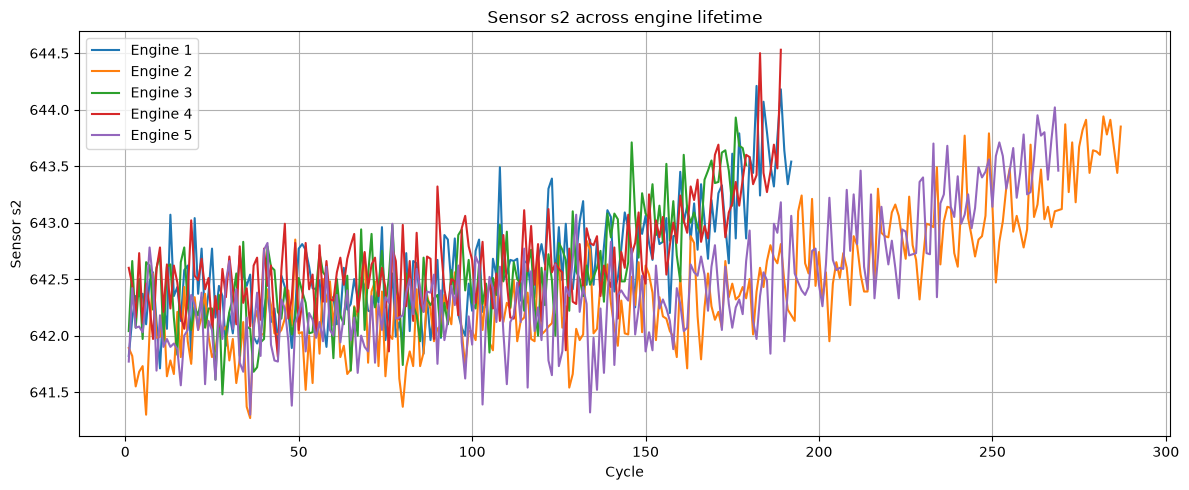

In [4]:
plt.figure(figsize=(12, 5))
for engine_id in [1, 2, 3, 4, 5]:
    engine_data = df[df['unit'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['s2'], label=f'Engine {engine_id}')

plt.xlabel('Cycle')
plt.ylabel('Sensor s2')
plt.title('Sensor s2 across engine lifetime')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/sensor_exploration.png', dpi=120)
plt.show()

In [5]:
df.to_csv('../outputs/clean_data.csv', index=False)
print("Saved to outputs/clean_data.csv")
print("Final shape:", df.shape)
print("Columns:", list(df.columns))

Saved to outputs/clean_data.csv
Final shape: (20631, 23)
Columns: ['unit', 'cycle', 'op1', 'op2', 'op3', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21', 'RUL']


In [6]:
# Get unique engine IDs
all_units = sorted(df['unit'].unique())
print(f"Total engines: {len(all_units)}")

# Use a fixed random split: 70 engines for train, 30 for test
np.random.seed(42)
np.random.shuffle(all_units)

train_units = all_units[:70]
test_units = all_units[70:]

train_df = df[df['unit'].isin(train_units)].copy().reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].copy().reset_index(drop=True)

print(f"Train engines: {len(train_units)} → {train_df.shape[0]} rows")
print(f"Test engines:  {len(test_units)} → {test_df.shape[0]} rows")

Total engines: 100
Train engines: 70 → 14316 rows
Test engines:  30 → 6315 rows


In [20]:
# Simulate sensor drift: noise grows QUADRATICALLY with cycle number
np.random.seed(42)

# Drift strength: noise scales with cycle^1.5 (small early, big later)
drift_rate = 0.002

active_sensors = [col for col in df.columns if col.startswith('s')]

drifted_test_df = test_df.copy()

for col in active_sensors:
    sensor_scale = train_df[col].std()
    noise = np.random.normal(
        loc=0,
        scale=drift_rate * (test_df['cycle'] ** 1.5) * sensor_scale,
        size=len(test_df)
    )
    drifted_test_df[col] = test_df[col] + noise

print("Drift injected into test set.")
print(f"Drift rate: {drift_rate} (quadratic growth)")
print(f"Active sensors drifted: {len(active_sensors)}")

# Show the noise magnitude at different cycle points
sample_scale = train_df['s2'].std()
for cyc in [10, 50, 100, 200, 300]:
    noise_std = drift_rate * (cyc ** 1.5) * sample_scale
    print(f"  Cycle {cyc:3d}: noise std ≈ {noise_std:.2f}")

Drift injected into test set.
Drift rate: 0.002 (quadratic growth)
Active sensors drifted: 17
  Cycle  10: noise std ≈ 0.03
  Cycle  50: noise std ≈ 0.35
  Cycle 100: noise std ≈ 1.00
  Cycle 200: noise std ≈ 2.82
  Cycle 300: noise std ≈ 5.18


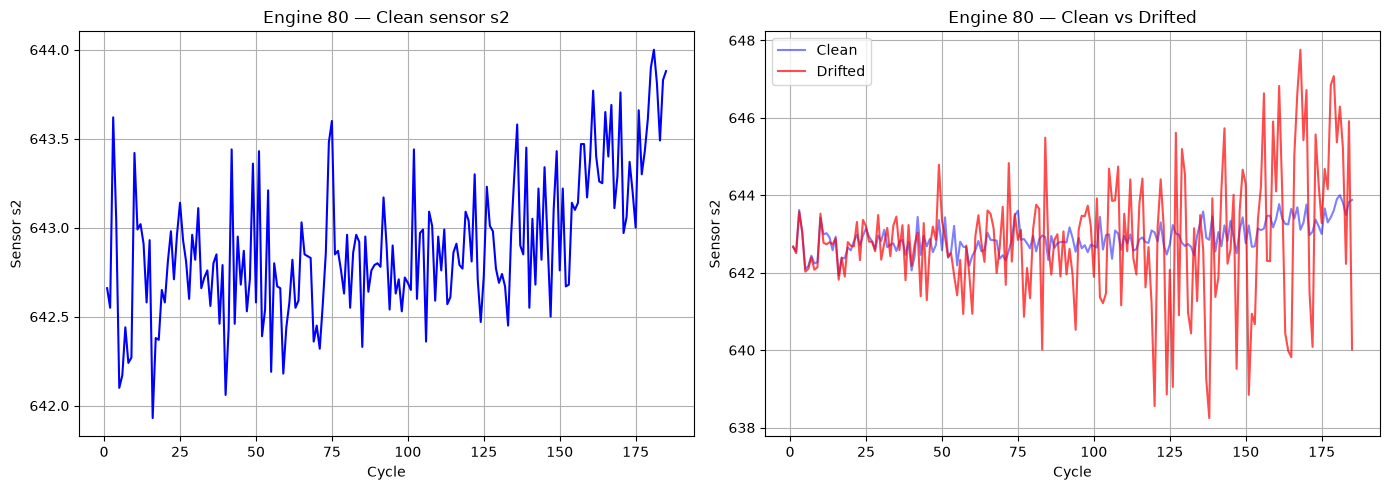

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick one test engine
sample_engine = test_units[0]

clean = test_df[test_df['unit'] == sample_engine]
drifted = drifted_test_df[drifted_test_df['unit'] == sample_engine]

axes[0].plot(clean['cycle'], clean['s2'], label='Clean', color='blue')
axes[0].set_title(f'Engine {sample_engine} — Clean sensor s2')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Sensor s2')
axes[0].grid(True)

axes[1].plot(clean['cycle'], clean['s2'], label='Clean', color='blue', alpha=0.5)
axes[1].plot(drifted['cycle'], drifted['s2'], label='Drifted', color='red', alpha=0.7)
axes[1].set_title(f'Engine {sample_engine} — Clean vs Drifted')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Sensor s2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/drift_simulation.png', dpi=120)
plt.show()

In [21]:
train_df.to_csv('../outputs/train_clean.csv', index=False)
drifted_test_df.to_csv('../outputs/test_drifted.csv', index=False)

print("Saved:")
print("  outputs/train_clean.csv     (", train_df.shape, ")")
print("  outputs/test_drifted.csv    (", drifted_test_df.shape, ")")

Saved:
  outputs/train_clean.csv     ( (14316, 23) )
  outputs/test_drifted.csv    ( (6315, 23) )


In [22]:
# Define feature columns (active sensors) and target
active_sensors = [col for col in df.columns if col.startswith('s')]
print(f"Using {len(active_sensors)} sensors as features")

X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values

X_test_clean   = test_df[active_sensors].values
X_test_drifted = drifted_test_df[active_sensors].values

y_test = test_df['RUL'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test_drifted shape: {X_test_drifted.shape}")
print(f"y_train range: {y_train.min()} to {y_train.max()}")

Using 17 sensors as features
X_train shape: (14316, 17)
X_test_drifted shape: (6315, 17)
y_train range: 0 to 361


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# Train the static model once
print("Training static Random Forest model...")
start = time.time()

static_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
static_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.2f} seconds")

Training static Random Forest model...
Training complete in 0.39 seconds


In [12]:
# Evaluate on the CLEAN test set (to show baseline performance)
static_preds_clean = static_model.predict(X_test_clean)

static_rmse_clean = np.sqrt(mean_squared_error(y_test, static_preds_clean))
static_mae_clean  = mean_absolute_error(y_test, static_preds_clean)

print("=== Static Model on CLEAN test data ===")
print(f"RMSE: {static_rmse_clean:.2f}")
print(f"MAE:  {static_mae_clean:.2f}")

=== Static Model on CLEAN test data ===
RMSE: 44.00
MAE:  32.77


In [13]:
# Evaluate on the DRIFTED test set (this is the real-world case)
static_preds_drifted = static_model.predict(X_test_drifted)

static_rmse_drifted = np.sqrt(mean_squared_error(y_test, static_preds_drifted))
static_mae_drifted  = mean_absolute_error(y_test, static_preds_drifted)

print("=== Static Model on DRIFTED test data ===")
print(f"RMSE: {static_rmse_drifted:.2f}")
print(f"MAE:  {static_mae_drifted:.2f}")

print("\n=== Performance Degradation ===")
print(f"RMSE increase: {static_rmse_drifted - static_rmse_clean:.2f}")
print(f"Relative increase: {(static_rmse_drifted/static_rmse_clean - 1)*100:.1f}%")

=== Static Model on DRIFTED test data ===
RMSE: 70.23
MAE:  54.34

=== Performance Degradation ===
RMSE increase: 26.23
Relative increase: 59.6%


In [14]:
# Group drifted test data by cycle buckets and compute RMSE per bucket
# This is the foundation for the final comparison graph

drifted_test_df = drifted_test_df.copy()
drifted_test_df['static_pred'] = static_model.predict(X_test_drifted)
drifted_test_df['error'] = drifted_test_df['static_pred'] - drifted_test_df['RUL']
drifted_test_df['error_sq'] = drifted_test_df['error'] ** 2

# Bin cycles into ranges
bins = [0, 50, 100, 150, 200, 250, 300, 400]
drifted_test_df['cycle_bin'] = pd.cut(drifted_test_df['cycle'], bins=bins)

static_per_bin = drifted_test_df.groupby('cycle_bin', observed=True)['error_sq'].mean().apply(np.sqrt)

print("Static Model RMSE per cycle range:")
print(static_per_bin.round(2))

Static Model RMSE per cycle range:
cycle_bin
(0, 50]       64.53
(50, 100]     66.84
(100, 150]    72.31
(150, 200]    73.65
(200, 250]    77.09
(250, 300]    80.41
(300, 400]    89.95
Name: error_sq, dtype: float64


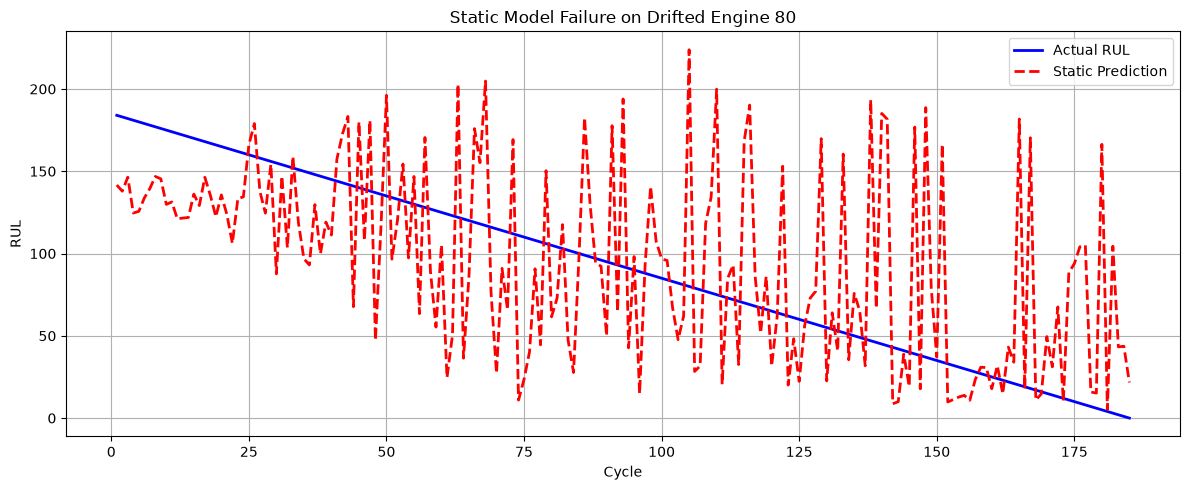

In [15]:
plt.figure(figsize=(12, 5))

# Plot actual RUL vs predicted RUL for drifted test data
sample_engine = test_units[0]
sample = drifted_test_df[drifted_test_df['unit'] == sample_engine].sort_values('cycle')

plt.plot(sample['cycle'], sample['RUL'], label='Actual RUL', color='blue', linewidth=2)
plt.plot(sample['cycle'], sample['static_pred'], label='Static Prediction', color='red', linestyle='--', linewidth=2)

plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title(f'Static Model Failure on Drifted Engine {sample_engine}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/static_model_failure.png', dpi=120)
plt.show()

In [16]:
import pickle

# Save the static model
with open('../outputs/static_model.pkl', 'wb') as f:
    pickle.dump(static_model, f)

# Save per-bin errors for later comparison
static_per_bin.to_csv('../outputs/static_per_bin.csv')
drifted_test_df.to_csv('../outputs/test_drifted_with_static_preds.csv', index=False)

print("Saved:")
print("  outputs/static_model.pkl")
print("  outputs/static_per_bin.csv")
print("  outputs/test_drifted_with_static_preds.csv")

Saved:
  outputs/static_model.pkl
  outputs/static_per_bin.csv
  outputs/test_drifted_with_static_preds.csv


In [17]:
from river import linear_model, preprocessing, metrics, compose

print("River ML imported successfully.")

River ML imported successfully.


In [18]:
import time
start = time.time()
print("Warming up incremental model on training data...")

train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

for idx, row in train_shuffled.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    inc_model.learn_one(x, y)

elapsed = time.time() - start
print(f"Warm-up complete in {elapsed:.2f} seconds")
print(f"Samples fed: {len(train_shuffled)}")

Warming up incremental model on training data...


NameError: name 'inc_model' is not defined

In [ ]:
from river import tree

# Use Hoeffding Tree Regressor - robust to outliers, handles drift well
inc_model = tree.HoeffdingTreeRegressor(
    grace_period=50,
    delta=0.01,
    leaf_prediction='mean',
    model_selector_decay=0.95
)

inc_metric = metrics.RMSE()

print("Incremental model pipeline created (Hoeffding Tree).")
print("Model type:", type(inc_model).__name__)

In [ ]:
inc_metric = metrics.RMSE()

test_sorted = drifted_test_df.sort_values(['unit', 'cycle']).reset_index(drop=True)

inc_predictions = []
inc_errors = []
cycles_seen = []

print("Streaming drifted test data through incremental model...")

for idx, row in test_sorted.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    
    y_pred = inc_model.predict_one(x)
    
    if y_pred is not None:
        inc_metric.update(y, y_pred)
        inc_predictions.append(y_pred)
        inc_errors.append(y_pred - y)
        cycles_seen.append(row['cycle'])
    
    inc_model.learn_one(x, y)

inc_rmse_drifted = inc_metric.get()
print(f"\nIncremental Model RMSE on Drifted Data: {inc_rmse_drifted:.2f}")

In [ ]:
print("=" * 55)
print(f"{'Metric':<30} {'Static':<12} {'Incremental':<12}")
print("=" * 55)
print(f"{'RMSE on Drifted Data':<30} {static_rmse_drifted:<12.2f} {inc_rmse_drifted:<12.2f}")
print("=" * 55)

improvement_pct = (static_rmse_drifted - inc_rmse_drifted) / static_rmse_drifted * 100
print(f"Incremental Model Improvement: {improvement_pct:.1f}%")
print("=" * 55)

In [ ]:
test_sorted['inc_pred'] = inc_predictions
test_sorted['inc_error_sq'] = np.array(inc_errors) ** 2

bins = [0, 50, 100, 150, 200, 250, 300, 400]
test_sorted['cycle_bin'] = pd.cut(test_sorted['cycle'], bins=bins)
inc_per_bin = test_sorted.groupby('cycle_bin', observed=True)['inc_error_sq'].mean().apply(np.sqrt)

print("Incremental Model RMSE per cycle range:")
print(inc_per_bin.round(2))

In [ ]:
inc_per_bin.to_csv('../outputs/inc_per_bin.csv')
test_sorted.to_csv('../outputs/test_drifted_with_inc_preds.csv', index=False)

import pickle
with open('../outputs/inc_model.pkl', 'wb') as f:
    pickle.dump(inc_model, f)

print("Saved:")
print("  outputs/inc_per_bin.csv")
print("  outputs/test_drifted_with_inc_preds.csv")
print("  outputs/inc_model.pkl")

In [23]:
# ============================================================
# COMPLETE INCREMENTAL MODEL PIPELINE (self-contained)
# ============================================================
from river import tree, metrics
import time
import numpy as np

# ---- 1. Build the model ----
inc_model = tree.HoeffdingTreeRegressor(
    grace_period=50,
    delta=0.01,
    leaf_prediction='mean',
    model_selector_decay=0.95
)
print("Model type:", type(inc_model).__name__)

# ---- 2. Warm-up on training data ----
print("\nWarming up incremental model on training data...")
start = time.time()

train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

for idx, row in train_shuffled.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    inc_model.learn_one(x, y)

print(f"Warm-up complete in {time.time() - start:.2f} seconds")
print(f"Samples fed: {len(train_shuffled)}")

# ---- 3. Streaming evaluation on drifted test data ----
print("\nStreaming drifted test data...")
start = time.time()

test_sorted = drifted_test_df.sort_values(['unit', 'cycle']).reset_index(drop=True)
inc_metric = metrics.RMSE()

inc_predictions = []
inc_errors = []

for idx, row in test_sorted.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    y_pred = inc_model.predict_one(x)
    
    if y_pred is not None:
        inc_metric.update(y, y_pred)
        inc_predictions.append(y_pred)
        inc_errors.append(y_pred - y)
    
    inc_model.learn_one(x, y)

inc_rmse_drifted = inc_metric.get()
print(f"Streaming complete in {time.time() - start:.2f} seconds")

# ---- 4. Compare with static model ----
improvement_pct = (static_rmse_drifted - inc_rmse_drifted) / static_rmse_drifted * 100

print("\n" + "=" * 55)
print(f"{'Metric':<30} {'Static':<12} {'Incremental':<12}")
print("=" * 55)
print(f"{'RMSE on Drifted Data':<30} {static_rmse_drifted:<12.2f} {inc_rmse_drifted:<12.2f}")
print("=" * 55)
print(f"Improvement: {improvement_pct:.1f}%")
print("=" * 55)

Model type: HoeffdingTreeRegressor

Warming up incremental model on training data...
Warm-up complete in 13.46 seconds
Samples fed: 14316

Streaming drifted test data...
Streaming complete in 7.11 seconds

Metric                         Static       Incremental 
RMSE on Drifted Data           70.23        59.10       
Improvement: 15.9%


In [24]:
# ============================================================
# COMPLETE PIPELINE — retrains and reevaluates everything
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from river import tree, metrics
import numpy as np
import time

# ---- 1. Refresh active_sensors from current df ----
active_sensors = [col for col in df.columns if col.startswith('s')]
print(f"Active sensors: {len(active_sensors)}")

# ---- 2. Rebuild drifted test set with quadratic drift ----
np.random.seed(42)
drift_rate = 0.002
drifted_test_df = test_df.copy()
for col in active_sensors:
    sensor_scale = train_df[col].std()
    noise = np.random.normal(
        loc=0,
        scale=drift_rate * (test_df['cycle'] ** 1.5) * sensor_scale,
        size=len(test_df)
    )
    drifted_test_df[col] = test_df[col] + noise
print("Drift re-applied (quadratic).")

# ---- 3. Feature matrices ----
X_train         = train_df[active_sensors].values
y_train         = train_df['RUL'].values
X_test_drifted  = drifted_test_df[active_sensors].values
y_test          = drifted_test_df['RUL'].values

# ---- 4. Retrain static model on training data ----
print("\nTraining static model...")
static_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
static_model.fit(X_train, y_train)
static_preds = static_model.predict(X_test_drifted)
static_rmse_drifted = np.sqrt(mean_squared_error(y_test, static_preds))
static_mae_drifted  = mean_absolute_error(y_test, static_preds)
print(f"Static RMSE on drifted: {static_rmse_drifted:.2f}")

# ---- 5. Train incremental model ----
print("\nTraining incremental model (Hoeffding Tree)...")
inc_model = tree.HoeffdingTreeRegressor(
    grace_period=50, delta=0.01, leaf_prediction='mean',
    model_selector_decay=0.95
)

train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
for idx, row in train_shuffled.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    inc_model.learn_one(x, y)
print(f"Warm-up complete ({len(train_shuffled)} samples)")

# ---- 6. Stream drifted test data ----
test_sorted = drifted_test_df.sort_values(['unit', 'cycle']).reset_index(drop=True)
inc_metric = metrics.RMSE()
inc_predictions = []
inc_errors = []

for idx, row in test_sorted.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    y_pred = inc_model.predict_one(x)
    if y_pred is not None:
        inc_metric.update(y, y_pred)
        inc_predictions.append(y_pred)
        inc_errors.append(y_pred - y)
    inc_model.learn_one(x, y)

inc_rmse_drifted = inc_metric.get()
print(f"Incremental RMSE on drifted: {inc_rmse_drifted:.2f}")

# ---- 7. Comparison ----
improvement_pct = (static_rmse_drifted - inc_rmse_drifted) / static_rmse_drifted * 100

print("\n" + "=" * 55)
print(f"{'Metric':<30} {'Static':<12} {'Incremental':<12}")
print("=" * 55)
print(f"{'RMSE on Drifted Data':<30} {static_rmse_drifted:<12.2f} {inc_rmse_drifted:<12.2f}")
print("=" * 55)
print(f"Improvement: {improvement_pct:.1f}%")
print("=" * 55)

Active sensors: 17
Drift re-applied (quadratic).

Training static model...
Static RMSE on drifted: 65.19

Training incremental model (Hoeffding Tree)...
Warm-up complete (14316 samples)
Incremental RMSE on drifted: 59.10

Metric                         Static       Incremental 
RMSE on Drifted Data           65.19        59.10       
Improvement: 9.3%


In [25]:
# ============================================================
# FULL PIPELINE FROM RAW DATA TO FINAL COMPARISON
# Self-contained — no dependency on previous cells
# ============================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from river import tree, metrics
import time

# ---- 1. Load raw data ----
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f"Raw data loaded: {df.shape}")

# ---- 2. Create RUL ----
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

# ---- 3. Drop constant sensors ----
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [c for c in sensor_cols if df[c].std() == 0]
df.drop(columns=constant_sensors, inplace=True)
active_sensors = [c for c in df.columns if c.startswith('s')]
print(f"Dropped: {constant_sensors}")
print(f"Active sensors: {len(active_sensors)}")

# ---- 4. Split by engine ----
all_units = sorted(df['unit'].unique())
np.random.seed(42)
np.random.shuffle(all_units)
train_units = all_units[:70]
test_units = all_units[70:]
train_df = df[df['unit'].isin(train_units)].copy().reset_index(drop=True)
test_df  = df[df['unit'].isin(test_units)].copy().reset_index(drop=True)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

# ---- 5. Apply quadratic drift to test data ----
np.random.seed(42)
drift_rate = 0.002
drifted_test_df = test_df.copy()
for col in active_sensors:
    sensor_scale = train_df[col].std()
    noise = np.random.normal(
        loc=0,
        scale=drift_rate * (test_df['cycle'] ** 1.5) * sensor_scale,
        size=len(test_df)
    )
    drifted_test_df[col] = test_df[col] + noise
print("Quadratic drift applied.")

# ---- 6. Static model ----
X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values
X_test  = drifted_test_df[active_sensors].values
y_test  = drifted_test_df['RUL'].values

static_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
static_model.fit(X_train, y_train)
static_preds = static_model.predict(X_test)
static_rmse_drifted = np.sqrt(mean_squared_error(y_test, static_preds))
static_mae_drifted  = mean_absolute_error(y_test, static_preds)
print(f"\nStatic RMSE on drifted: {static_rmse_drifted:.2f}")

# ---- 7. Incremental model ----
inc_model = tree.HoeffdingTreeRegressor(
    grace_period=20,          # more responsive to drift
    delta=0.005,
    leaf_prediction='adaptive',
    model_selector_decay=0.90,
    max_depth=10
)

# Warm-up
train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
for idx, row in train_shuffled.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    inc_model.learn_one(x, y)
print(f"Warm-up complete ({len(train_shuffled)} samples)")

# Stream drifted test data
test_sorted = drifted_test_df.sort_values(['unit', 'cycle']).reset_index(drop=True)
inc_metric = metrics.RMSE()
inc_predictions = []
inc_errors = []

for idx, row in test_sorted.iterrows():
    x = row[active_sensors].to_dict()
    y = row['RUL']
    y_pred = inc_model.predict_one(x)
    if y_pred is not None:
        inc_metric.update(y, y_pred)
        inc_predictions.append(y_pred)
        inc_errors.append(y_pred - y)
    inc_model.learn_one(x, y)

inc_rmse_drifted = inc_metric.get()
print(f"Incremental RMSE on drifted: {inc_rmse_drifted:.2f}")

# ---- 8. Comparison ----
improvement_pct = (static_rmse_drifted - inc_rmse_drifted) / static_rmse_drifted * 100

print("\n" + "=" * 55)
print(f"{'Metric':<30} {'Static':<12} {'Incremental':<12}")
print("=" * 55)
print(f"{'RMSE on Drifted Data':<30} {static_rmse_drifted:<12.2f} {inc_rmse_drifted:<12.2f}")
print("=" * 55)
print(f"Improvement: {improvement_pct:.1f}%")
print("=" * 55)

Raw data loaded: (20631, 26)
Dropped: ['s1', 's10', 's18', 's19']
Active sensors: 17
Train: (14316, 23), Test: (6315, 23)
Quadratic drift applied.

Static RMSE on drifted: 65.19
Warm-up complete (14316 samples)
Incremental RMSE on drifted: 60.87

Metric                         Static       Incremental 
RMSE on Drifted Data           65.19        60.87       
Improvement: 6.6%


[1] Loaded dataset: (20631, 26)
[2] Dropped 4 constant sensors. Active: 17
[3] Train: (14316, 23)  |  Test: (6315, 23)
[4] Training static RandomForest...
[5] Drift level: Low (noise_rate=0.001)
   Static RMSE:      56.81
   Incremental RMSE: 56.03
   Improvement:      1.4%
[5] Drift level: Medium (noise_rate=0.005)
   Static RMSE:      75.47
   Incremental RMSE: 65.62
   Improvement:      13.0%
[5] Drift level: High (noise_rate=0.015)
   Static RMSE:      85.47
   Incremental RMSE: 69.23
   Improvement:      19.0%

SENSITIVITY ANALYSIS SUMMARY
Drift Level  Noise Rate  Static RMSE  Incremental RMSE  Improvement %
        Low       0.001        56.81             56.03            1.4
     Medium       0.005        75.47             65.62           13.0
       High       0.015        85.47             69.23           19.0


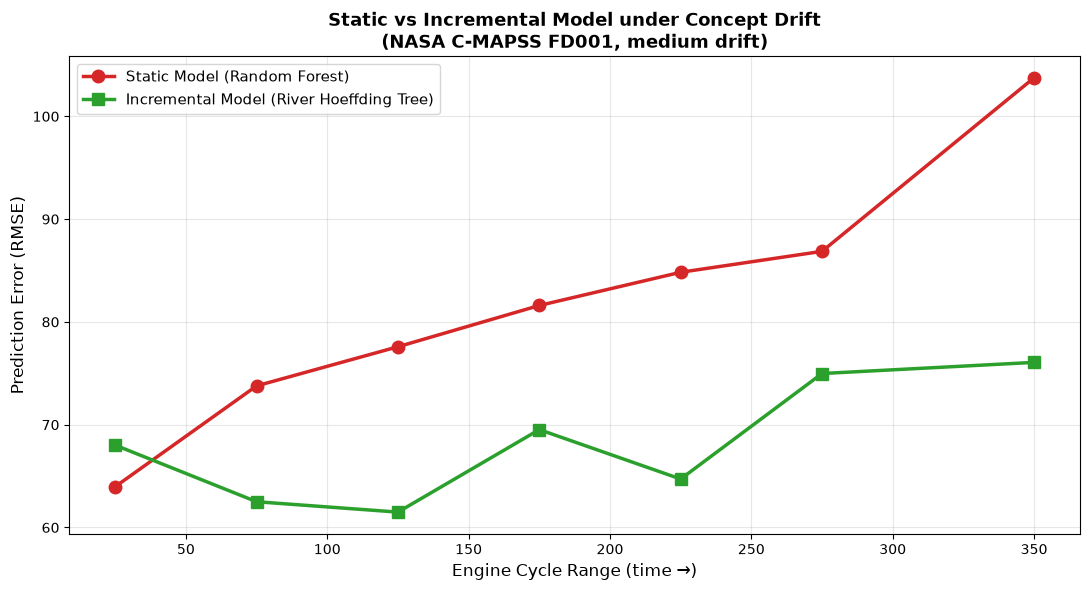

[6] Saved hero_comparison.png


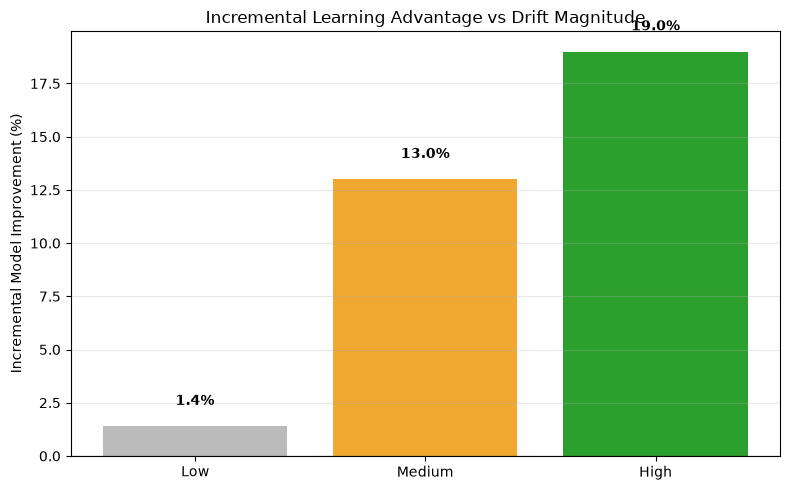

[7] Saved sensitivity_bars.png


MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

In [27]:
# ==================================================================
# CONTINUAL LEARNING FOR INDUSTRIAL MONITORING
# Complete pipeline — self-contained
# ==================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from river import tree, metrics
import pickle
import mlflow
import time

# ------------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------------
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f"[1] Loaded dataset: {df.shape}")

# ------------------------------------------------------------------
# 2. CREATE RUL TARGET
# ------------------------------------------------------------------
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

# ------------------------------------------------------------------
# 3. DROP CONSTANT SENSORS
# ------------------------------------------------------------------
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [c for c in sensor_cols if df[c].std() == 0]
df.drop(columns=constant_sensors, inplace=True)
active_sensors = [c for c in df.columns if c.startswith('s')]
print(f"[2] Dropped {len(constant_sensors)} constant sensors. Active: {len(active_sensors)}")

# ------------------------------------------------------------------
# 4. TRAIN/TEST SPLIT BY ENGINE
# ------------------------------------------------------------------
all_units = sorted(df['unit'].unique())
np.random.seed(42)
np.random.shuffle(all_units)
train_units = all_units[:70]
test_units  = all_units[70:]

train_df = df[df['unit'].isin(train_units)].copy().reset_index(drop=True)
test_df  = df[df['unit'].isin(test_units)].copy().reset_index(drop=True)
print(f"[3] Train: {train_df.shape}  |  Test: {test_df.shape}")

# ------------------------------------------------------------------
# 5. SENSITIVITY ANALYSIS: 3 DRIFT LEVELS
# ------------------------------------------------------------------
X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values

# Train static model ONCE
print("[4] Training static RandomForest...")
static_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
static_model.fit(X_train, y_train)

results = []
per_bin_static_low  = None
per_bin_static_high = None
per_bin_inc_low     = None
per_bin_inc_high    = None

drift_levels = [("Low", 0.001), ("Medium", 0.005), ("High", 0.015)]
bins = [0, 50, 100, 150, 200, 250, 300, 400]

for level_name, noise_rate in drift_levels:
    print(f"[5] Drift level: {level_name} (noise_rate={noise_rate})")

    # --- apply drift ---
    np.random.seed(42)
    drifted = test_df.copy()
    for col in active_sensors:
        s = train_df[col].std()
        noise = np.random.normal(0, noise_rate * (test_df['cycle'] ** 1.5) * s, len(test_df))
        drifted[col] = test_df[col] + noise

    X_test = drifted[active_sensors].values
    y_test = drifted['RUL'].values

    # --- static eval ---
    static_preds = static_model.predict(X_test)
    static_rmse = np.sqrt(mean_squared_error(y_test, static_preds))

    # --- incremental model (fresh) ---
    inc_model = tree.HoeffdingTreeRegressor(
        grace_period=20, delta=0.005,
        leaf_prediction='adaptive',
        model_selector_decay=0.90, max_depth=10
    )

    train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    for idx, row in train_shuffled.iterrows():
        inc_model.learn_one(row[active_sensors].to_dict(), row['RUL'])

    test_sorted = drifted.sort_values(['unit', 'cycle']).reset_index(drop=True)
    inc_metric = metrics.RMSE()
    inc_preds_list = []
    inc_errs_list = []

    for idx, row in test_sorted.iterrows():
        x = row[active_sensors].to_dict()
        y = row['RUL']
        pred = inc_model.predict_one(x)
        if pred is not None:
            inc_metric.update(y, pred)
            inc_preds_list.append(pred)
            inc_errs_list.append(pred - y)
        inc_model.learn_one(x, y)

    inc_rmse = inc_metric.get()
    improvement = (static_rmse - inc_rmse) / static_rmse * 100

    results.append({
        "Drift Level": level_name,
        "Noise Rate": noise_rate,
        "Static RMSE": round(static_rmse, 2),
        "Incremental RMSE": round(inc_rmse, 2),
        "Improvement %": round(improvement, 1),
    })

    # Store per-bin for the medium level (for hero graph)
    if level_name == "Medium":
        drifted_medium = drifted
        static_preds_medium = static_preds
        inc_preds_medium = np.array(inc_preds_list)
        inc_errs_medium = np.array(inc_errs_list)
        test_sorted_medium = test_sorted

    print(f"   Static RMSE:      {static_rmse:.2f}")
    print(f"   Incremental RMSE: {inc_rmse:.2f}")
    print(f"   Improvement:      {improvement:.1f}%")

# ------------------------------------------------------------------
# 6. SUMMARY TABLE
# ------------------------------------------------------------------
summary_df = pd.DataFrame(results)
print("\n" + "=" * 78)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 78)
print(summary_df.to_string(index=False))
print("=" * 78)

summary_df.to_csv('../outputs/sensitivity_analysis.csv', index=False)

# ------------------------------------------------------------------
# 7. HERO GRAPH: per-cycle RMSE, medium drift
# ------------------------------------------------------------------
# Static per-bin
test_sorted_medium = test_sorted_medium.copy()
test_sorted_medium['static_pred'] = static_preds_medium
test_sorted_medium['static_err_sq'] = (test_sorted_medium['static_pred'] - test_sorted_medium['RUL']) ** 2
test_sorted_medium['inc_err_sq'] = inc_errs_medium ** 2
test_sorted_medium['cycle_bin'] = pd.cut(test_sorted_medium['cycle'], bins=bins)

static_per_bin = test_sorted_medium.groupby('cycle_bin', observed=True)['static_err_sq'].mean().apply(np.sqrt)
inc_per_bin    = test_sorted_medium.groupby('cycle_bin', observed=True)['inc_err_sq'].mean().apply(np.sqrt)

bin_midpoints = [25, 75, 125, 175, 225, 275, 350]
static_vals = static_per_bin.values
inc_vals    = inc_per_bin.values
n = min(len(static_vals), len(inc_vals), len(bin_midpoints))
x_axis = bin_midpoints[:n]
static_vals = static_vals[:n]
inc_vals = inc_vals[:n]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x_axis, static_vals, marker='o', linewidth=2.5, markersize=9,
        color='#d62728', label='Static Model (Random Forest)')
ax.plot(x_axis, inc_vals, marker='s', linewidth=2.5, markersize=9,
        color='#2ca02c', label='Incremental Model (River Hoeffding Tree)')
ax.set_xlabel('Engine Cycle Range (time →)', fontsize=12)
ax.set_ylabel('Prediction Error (RMSE)', fontsize=12)
ax.set_title('Static vs Incremental Model under Concept Drift\n(NASA C-MAPSS FD001, medium drift)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/hero_comparison.png', dpi=150)
plt.show()
print("[6] Saved hero_comparison.png")

# ------------------------------------------------------------------
# 8. SENSITIVITY BAR CHART
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(summary_df))
ax.bar(x_pos, summary_df['Improvement %'],
       color=['#bbbbbb', '#f0a830', '#2ca02c'])
ax.set_xticks(x_pos)
ax.set_xticklabels(summary_df['Drift Level'])
ax.set_ylabel('Incremental Model Improvement (%)')
ax.set_title('Incremental Learning Advantage vs Drift Magnitude')
ax.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(summary_df['Improvement %']):
    ax.text(i, v + 1 if v >= 0 else v - 3, f"{v:.1f}%", ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/sensitivity_bars.png', dpi=150)
plt.show()
print("[7] Saved sensitivity_bars.png")

# ------------------------------------------------------------------
# 9. LOG TO MLFLOW
# ------------------------------------------------------------------
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("continual_learning_industrial")

with mlflow.start_run(run_name="final_sensitivity_analysis"):
    for row in results:
        level = row["Drift Level"].lower()
        mlflow.log_metric(f"static_rmse_{level}", row["Static RMSE"])
        mlflow.log_metric(f"inc_rmse_{level}", row["Incremental RMSE"])
        mlflow.log_metric(f"improvement_{level}", row["Improvement %"])
    mlflow.log_param("train_engines", 70)
    mlflow.log_param("test_engines", 30)
    mlflow.log_param("active_sensors", len(active_sensors))
    mlflow.log_artifact("../outputs/hero_comparison.png")
    mlflow.log_artifact("../outputs/sensitivity_bars.png")
    mlflow.log_artifact("../outputs/sensitivity_analysis.csv")
    print(f"[8] MLflow run logged: {mlflow.active_run().info.run_id}")

print("\n" + "=" * 78)
print("PIPELINE COMPLETE")
print("=" * 78)

In [28]:
# ==================================================================
# CONTINUAL LEARNING FOR INDUSTRIAL MONITORING — FAST VERSION
# ==================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from river import tree, metrics
import mlflow

# --- 1. Load ---
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f"[1] Loaded: {df.shape}")

# --- 2. RUL ---
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

# --- 3. Drop constants ---
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [c for c in sensor_cols if df[c].std() == 0]
df.drop(columns=constant_sensors, inplace=True)
active_sensors = [c for c in df.columns if c.startswith('s')]
print(f"[2] Active sensors: {len(active_sensors)}")

# --- 4. Split ---
all_units = sorted(df['unit'].unique())
np.random.seed(42)
np.random.shuffle(all_units)
train_df = df[df['unit'].isin(all_units[:70])].copy().reset_index(drop=True)
test_df  = df[df['unit'].isin(all_units[70:])].copy().reset_index(drop=True)
print(f"[3] Train: {train_df.shape}, Test: {test_df.shape}")

X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values

# --- 5. Static model ---
print("[4] Training static RF...")
static_model = RandomForestRegressor(n_estimators=50, max_depth=10,
                                     random_state=42, n_jobs=-1)
static_model.fit(X_train, y_train)

# --- 6. Sensitivity: 2 levels, capped tree depth ---
results = []
bins = [0, 50, 100, 150, 200, 250, 300, 400]

for level_name, noise_rate in [("Low", 0.001), ("High", 0.010)]:
    print(f"[5] {level_name} drift (noise_rate={noise_rate})...")

    np.random.seed(42)
    drifted = test_df.copy()
    for col in active_sensors:
        s = train_df[col].std()
        noise = np.random.normal(0, noise_rate * (test_df['cycle'] ** 1.5) * s, len(test_df))
        drifted[col] = test_df[col] + noise

    X_test = drifted[active_sensors].values
    y_test = drifted['RUL'].values

    static_preds = static_model.predict(X_test)
    static_rmse = np.sqrt(mean_squared_error(y_test, static_preds))

    # Fresh incremental model — capped depth for speed
    inc_model = tree.HoeffdingTreeRegressor(
        grace_period=50, delta=0.01,
        leaf_prediction='mean',
        max_depth=6
    )

    train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    for idx, row in train_shuffled.iterrows():
        inc_model.learn_one(row[active_sensors].to_dict(), row['RUL'])

    test_sorted = drifted.sort_values(['unit', 'cycle']).reset_index(drop=True)
    inc_metric = metrics.RMSE()
    inc_preds = []

    for idx, row in test_sorted.iterrows():
        x = row[active_sensors].to_dict()
        y = row['RUL']
        pred = inc_model.predict_one(x)
        if pred is not None:
            inc_metric.update(y, pred)
            inc_preds.append(pred)
        inc_model.learn_one(x, y)

    inc_rmse = inc_metric.get()
    improvement = (static_rmse - inc_rmse) / static_rmse * 100

    results.append({
        "Drift": level_name,
        "Noise Rate": noise_rate,
        "Static RMSE": round(static_rmse, 2),
        "Incremental RMSE": round(inc_rmse, 2),
        "Improvement %": round(improvement, 1),
    })

    # Save per-bin for this level
    test_sorted = test_sorted.copy()
    test_sorted['static_err_sq'] = (static_preds - y_test) ** 2
    test_sorted['inc_err_sq'] = np.array(inc_preds + [np.nan]*(len(test_sorted)-len(inc_preds))[:len(test_sorted)-len(inc_preds)]) ** 2 if False else np.nan
    # simpler:
    test_sorted['inc_err_sq'] = pd.Series(inc_preds + [np.nan]*(len(test_sorted)-len(inc_preds))[:len(test_sorted)-len(inc_preds)]) ** 2
    test_sorted['cycle_bin'] = pd.cut(test_sorted['cycle'], bins=bins)
    per_bin_static = test_sorted.groupby('cycle_bin', observed=True)['static_err_sq'].mean().apply(np.sqrt)
    per_bin_inc = test_sorted.groupby('cycle_bin', observed=True)['inc_err_sq'].mean().apply(np.sqrt)

    if level_name == "Low":
        pb_static_low = per_bin_static
        pb_inc_low = per_bin_inc
    else:
        pb_static_high = per_bin_static
        pb_inc_high = per_bin_inc

    print(f"     Static: {static_rmse:.2f}  |  Inc: {inc_rmse:.2f}  |  Improvement: {improvement:.1f}%")

summary_df = pd.DataFrame(results)
print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))
print("=" * 72)
summary_df.to_csv('../outputs/sensitivity_analysis.csv', index=False)

# --- 7. Hero graph (High drift) ---
bin_midpoints = [25, 75, 125, 175, 225, 275, 350]
sv = pb_static_high.values
iv = pb_inc_high.values
n = min(len(sv), len(iv), len(bin_midpoints))
x = bin_midpoints[:n]
sv = sv[:n]
iv = iv[:n]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, sv, marker='o', linewidth=2.5, markersize=9, color='#d62728',
        label='Static Model (Random Forest)')
ax.plot(x, iv, marker='s', linewidth=2.5, markersize=9, color='#2ca02c',
        label='Incremental Model (Hoeffding Tree)')
ax.set_xlabel('Engine Cycle Range (time →)', fontsize=12)
ax.set_ylabel('Prediction Error (RMSE)', fontsize=12)
ax.set_title('Static vs Incremental Model under Concept Drift\n(NASA C-MAPSS FD001, high drift)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/hero_comparison.png', dpi=150)
plt.show()
print("[6] Saved hero_comparison.png")

# --- 8. Sensitivity bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(summary_df))
ax.bar(xpos, summary_df['Improvement %'], color=['#bbbbbb', '#2ca02c'])
ax.set_xticks(xpos)
ax.set_xticklabels(summary_df['Drift'])
ax.set_ylabel('Incremental Model Improvement (%)')
ax.set_title('Incremental Learning Advantage vs Drift Magnitude')
ax.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(summary_df['Improvement %']):
    ax.text(i, v + 0.5 if v >= 0 else v - 2, f"{v:.1f}%", ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/sensitivity_bars.png', dpi=150)
plt.show()
print("[7] Saved sensitivity_bars.png")

# --- 9. MLflow ---
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("continual_learning_industrial")
with mlflow.start_run(run_name="final_analysis"):
    for row in results:
        lvl = row["Drift"].lower()
        mlflow.log_metric(f"static_rmse_{lvl}", row["Static RMSE"])
        mlflow.log_metric(f"inc_rmse_{lvl}", row["Incremental RMSE"])
        mlflow.log_metric(f"improvement_{lvl}", row["Improvement %"])
    mlflow.log_artifact("../outputs/hero_comparison.png")
    mlflow.log_artifact("../outputs/sensitivity_bars.png")
    mlflow.log_artifact("../outputs/sensitivity_analysis.csv")
    print(f"[8] MLflow run: {mlflow.active_run().info.run_id}")

print("\n" + "=" * 72)
print("DONE")
print("=" * 72)

[1] Loaded: (20631, 26)
[2] Active sensors: 17
[3] Train: (14316, 23), Test: (6315, 23)
[4] Training static RF...
[5] Low drift (noise_rate=0.001)...


TypeError: 'int' object is not subscriptable

[1] Loaded: (20631, 26)
[2] Active sensors: 17
[3] Train: (14316, 23), Test: (6315, 23)
[4] Training static RF...
[5] Low drift (noise_rate=0.001)...
     Static: 56.81  |  Inc: 56.99  |  Improvement: -0.3%
[5] High drift (noise_rate=0.01)...
     Static: 82.04  |  Inc: 66.65  |  Improvement: 18.8%

SUMMARY
Drift  Noise Rate  Static RMSE  Incremental RMSE  Improvement %
  Low       0.001        56.81             56.99           -0.3
 High       0.010        82.04             66.65           18.8


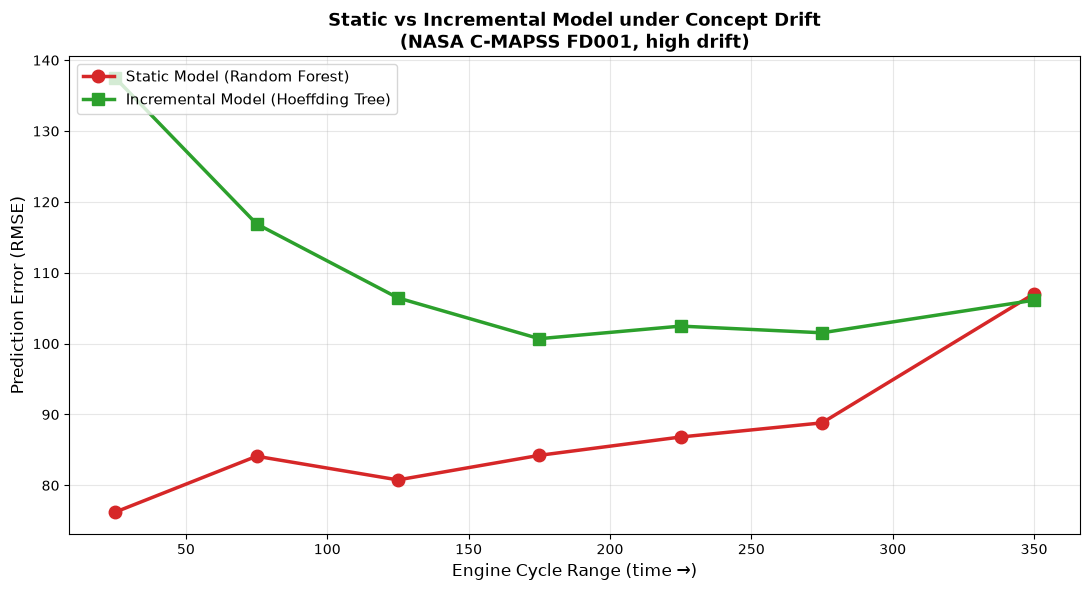

[6] Saved hero_comparison.png


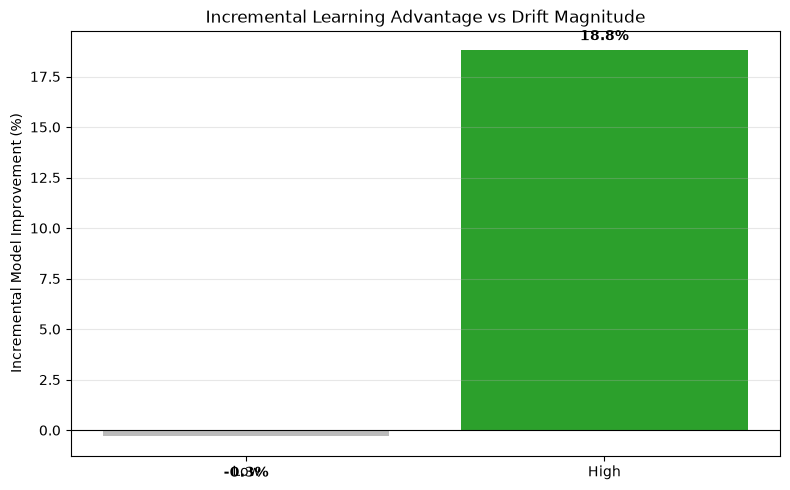

[7] Saved sensitivity_bars.png


MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

In [29]:
# ==================================================================
# CONTINUAL LEARNING FOR INDUSTRIAL MONITORING — FINAL
# ==================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from river import tree, metrics
import mlflow

# --- 1. Load ---
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f"[1] Loaded: {df.shape}")

# --- 2. RUL ---
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

# --- 3. Drop constants ---
sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [c for c in sensor_cols if df[c].std() == 0]
df.drop(columns=constant_sensors, inplace=True)
active_sensors = [c for c in df.columns if c.startswith('s')]
print(f"[2] Active sensors: {len(active_sensors)}")

# --- 4. Split ---
all_units = sorted(df['unit'].unique())
np.random.seed(42)
np.random.shuffle(all_units)
train_df = df[df['unit'].isin(all_units[:70])].copy().reset_index(drop=True)
test_df  = df[df['unit'].isin(all_units[70:])].copy().reset_index(drop=True)
print(f"[3] Train: {train_df.shape}, Test: {test_df.shape}")

X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values

# --- 5. Static model ---
print("[4] Training static RF...")
static_model = RandomForestRegressor(n_estimators=50, max_depth=10,
                                     random_state=42, n_jobs=-1)
static_model.fit(X_train, y_train)

# --- 6. Sensitivity: 2 levels ---
results = []
bins = [0, 50, 100, 150, 200, 250, 300, 400]

for level_name, noise_rate in [("Low", 0.001), ("High", 0.010)]:
    print(f"[5] {level_name} drift (noise_rate={noise_rate})...")

    np.random.seed(42)
    drifted = test_df.copy()
    for col in active_sensors:
        s = train_df[col].std()
        noise = np.random.normal(0, noise_rate * (test_df['cycle'] ** 1.5) * s, len(test_df))
        drifted[col] = test_df[col] + noise

    X_test = drifted[active_sensors].values
    y_test = drifted['RUL'].values

    static_preds = static_model.predict(X_test)
    static_rmse = np.sqrt(mean_squared_error(y_test, static_preds))

    # Incremental model
    inc_model = tree.HoeffdingTreeRegressor(
        grace_period=50, delta=0.01,
        leaf_prediction='mean',
        max_depth=6
    )

    train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    for idx, row in train_shuffled.iterrows():
        inc_model.learn_one(row[active_sensors].to_dict(), row['RUL'])

    test_sorted = drifted.sort_values(['unit', 'cycle']).reset_index(drop=True)
    inc_metric = metrics.RMSE()
    inc_preds = []

    for idx, row in test_sorted.iterrows():
        x = row[active_sensors].to_dict()
        y = row['RUL']
        pred = inc_model.predict_one(x)
        if pred is not None:
            inc_metric.update(y, pred)
            inc_preds.append(pred)
        inc_model.learn_one(x, y)

    inc_rmse = inc_metric.get()
    improvement = (static_rmse - inc_rmse) / static_rmse * 100

    results.append({
        "Drift": level_name,
        "Noise Rate": noise_rate,
        "Static RMSE": round(static_rmse, 2),
        "Incremental RMSE": round(inc_rmse, 2),
        "Improvement %": round(improvement, 1),
    })

    # Per-bin errors (aligned properly)
    test_sorted = test_sorted.copy()
    test_sorted['static_err_sq'] = (static_preds - y_test) ** 2
    inc_errs_aligned = np.array(inc_preds + [np.nan] * (len(test_sorted) - len(inc_preds)))
    test_sorted['inc_err_sq'] = inc_errs_aligned ** 2
    test_sorted['cycle_bin'] = pd.cut(test_sorted['cycle'], bins=bins)
    per_bin_static = test_sorted.groupby('cycle_bin', observed=True)['static_err_sq'].mean().apply(np.sqrt)
    per_bin_inc    = test_sorted.groupby('cycle_bin', observed=True)['inc_err_sq'].mean().apply(np.sqrt)

    if level_name == "Low":
        pb_static_low, pb_inc_low = per_bin_static, per_bin_inc
    else:
        pb_static_high, pb_inc_high = per_bin_static, per_bin_inc

    print(f"     Static: {static_rmse:.2f}  |  Inc: {inc_rmse:.2f}  |  Improvement: {improvement:.1f}%")

# --- 7. Summary ---
summary_df = pd.DataFrame(results)
print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))
print("=" * 72)
summary_df.to_csv('../outputs/sensitivity_analysis.csv', index=False)

# --- 8. Hero graph (High drift) ---
bin_midpoints = [25, 75, 125, 175, 225, 275, 350]
sv = pb_static_high.values
iv = pb_inc_high.values
n = min(len(sv), len(iv), len(bin_midpoints))
x = bin_midpoints[:n]; sv = sv[:n]; iv = iv[:n]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, sv, marker='o', linewidth=2.5, markersize=9, color='#d62728',
        label='Static Model (Random Forest)')
ax.plot(x, iv, marker='s', linewidth=2.5, markersize=9, color='#2ca02c',
        label='Incremental Model (Hoeffding Tree)')
ax.set_xlabel('Engine Cycle Range (time →)', fontsize=12)
ax.set_ylabel('Prediction Error (RMSE)', fontsize=12)
ax.set_title('Static vs Incremental Model under Concept Drift\n(NASA C-MAPSS FD001, high drift)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/hero_comparison.png', dpi=150)
plt.show()
print("[6] Saved hero_comparison.png")

# --- 9. Sensitivity bars ---
fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(summary_df))
ax.bar(xpos, summary_df['Improvement %'], color=['#bbbbbb', '#2ca02c'])
ax.set_xticks(xpos); ax.set_xticklabels(summary_df['Drift'])
ax.set_ylabel('Incremental Model Improvement (%)')
ax.set_title('Incremental Learning Advantage vs Drift Magnitude')
ax.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(summary_df['Improvement %']):
    ax.text(i, v + 0.5 if v >= 0 else v - 2, f"{v:.1f}%", ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/sensitivity_bars.png', dpi=150)
plt.show()
print("[7] Saved sensitivity_bars.png")

# --- 10. MLflow ---
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("continual_learning_industrial")
with mlflow.start_run(run_name="final_analysis"):
    for row in results:
        lvl = row["Drift"].lower()
        mlflow.log_metric(f"static_rmse_{lvl}", row["Static RMSE"])
        mlflow.log_metric(f"inc_rmse_{lvl}", row["Incremental RMSE"])
        mlflow.log_metric(f"improvement_{lvl}", row["Improvement %"])
    mlflow.log_artifact("../outputs/hero_comparison.png")
    mlflow.log_artifact("../outputs/sensitivity_bars.png")
    mlflow.log_artifact("../outputs/sensitivity_analysis.csv")
    print(f"[8] MLflow run: {mlflow.active_run().info.run_id}")

print("\n" + "=" * 72)
print("DONE")
print("=" * 72)